In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List
import numpy as np


from src.data_models.caravanify import Caravanify, CaravanifyConfig


---

In [3]:
def extract_source_basins_for_training(
    ca_groups_path: str, source_clusters_path: str, group_mappings: Dict
) -> Dict:
    """
    Extract source basins corresponding to CA target basins grouped by their major groups.

    Args:
        ca_groups_path: Path to CSV file with CA basin group assignments
        source_clusters_path: Path to CSV file with source basin cluster assignments
        group_mappings: Dictionary defining the mapping between groups and clusters

    Returns:
        Dictionary with training data structure organized by target groups
    """
    # Load the data
    ca_groups = pd.read_csv(ca_groups_path)
    source_clusters = pd.read_csv(source_clusters_path)

    training_data = {}

    # Process each group
    for group_key, group_info in group_mappings.items():
        # Get CA basins for this group
        ca_group_basins = ca_groups[
            ca_groups["major_group"] == group_info["ca_group_label"]
        ]["gauge_id"].tolist()

        # Get source basins for this group by cluster
        source_group_basins = source_clusters[
            source_clusters["cluster"].isin(group_info["clusters"])
        ]["gauge_id"].tolist()

        # Split source basins by country
        country_basins = {
            "CH": [basin for basin in source_group_basins if basin.startswith("CH_")],
            "USA": [basin for basin in source_group_basins if basin.startswith("USA_")],
            "CL": [basin for basin in source_group_basins if basin.startswith("CL_")],
        }

        # Store in training data structure
        training_data[group_key] = {
            "target": ca_group_basins,
            "source": country_basins,
        }

        # Print summary statistics
        print(f"{group_key} - CA target basins: {len(ca_group_basins)}")
        for country, basins in country_basins.items():
            print(f"{group_key} - {country} source basins: {len(basins)}")
        print()

    return training_data


def load_data_for_group(
    group_key: str,
    training_data: Dict,
    ca_config: Dict,
) -> Dict:
    """
    Load all data for a specific group using Caravanify.

    Args:
        group_key: Key of the group to load data for (e.g., 'group1')
        training_data: Dictionary with basin mapping information
        ca_config: Configuration for CA data
        ch_config: Configuration for Switzerland data
        usa_config: Configuration for USA data
        cl_config: Configuration for Chile data

    Returns:
        Dictionary with loaded time series and static data
    """
    print(f"Loading data for {group_key}...")

    # Get relevant basin IDs
    ca_basins = training_data[group_key]["target"]

    # Dictionary to store data from each country
    data = {
        "ca_ts_data": None,
        "ca_static_data": None,
    }

    # Load CA data
    ca_caravan_config = CaravanifyConfig(
        attributes_dir=ca_config["ATTRIBUTE_DIR"],
        timeseries_dir=ca_config["TIMESERIES_DIR"],
        gauge_id_prefix=ca_config["GAUGE_ID_PREFIX"],
        use_hydroatlas_attributes=True,
        use_caravan_attributes=True,
        use_other_attributes=True,
    )

    ca_caravan = Caravanify(ca_caravan_config)
    ca_caravan.load_stations(ca_basins)
    data["ca_ts_data"] = ca_caravan.get_time_series()
    data["ca_static_data"] = ca_caravan.get_static_attributes()

    return data

In [4]:
# Configuration for group mappings
group_mappings = {
    "group1": {
        "name": "Group 1 [13, 4]",
        "clusters": [13, 14],
        "ca_group_label": "Group 1 [13, 14]",
    }
}


# Path configuration
ca_groups_path = "/Users/cooper/Desktop/CAMELS-CH/classification_results/final_basin_assignments_for_shifted_15_clusters.csv"
source_clusters_path = "/Users/cooper/Desktop/CAMELS-CH/classification_results/cluster_probabilities_shifted_15_clusters.csv"

# Country configurations
ca_config = {
    "ATTRIBUTE_DIR": "/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    "TIMESERIES_DIR": "/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    "GAUGE_ID_PREFIX": "CA",
    "MIN_TRAIN_YEARS": 8,
    "VAL_YEARS": 2,
    "TEST_YEARS": 5,
    "MAX_MISSING_PCT": 15,
}

# Step 1: Extract source basins for training
training_data = extract_source_basins_for_training(
    ca_groups_path="/Users/cooper/Desktop/CAMELS-CH/classification_results/final_basin_assignments_for_shifted_15_clusters.csv",  # Path to CA groups CSV
    source_clusters_path="/Users/cooper/Desktop/CAMELS-CH/clustering_results/cluster_assignments_shifted.csv",  # Path to source clusters CSV
    group_mappings=group_mappings,  # Group mappings
)


# Step 2: Load data for a specific group
group_keys = ["group1"]

group_data = load_data_for_group(
    group_key=group_keys[0],
    training_data=training_data,
    ca_config=ca_config,
)

# Access the loaded data
print(f"CA time series data shape: {group_data['ca_ts_data'].shape}")
print(f"CA static data shape: {group_data['ca_static_data'].shape}")

group1 - CA target basins: 78
group1 - CH source basins: 66
group1 - USA source basins: 105
group1 - CL source basins: 40

Loading data for group1...
CA time series data shape: (712218, 42)
CA static data shape: (78, 216)


In [11]:
path_to_csv = "/Users/cooper/Desktop/CAMELS-CH/classification_results/final_basin_assignments_for_shifted_15_clusters.csv"


def get_ids_from_cluster(
    cluster_assignments: pd.DataFrame,
    cluster_id: int,
    group_data: Dict,
) -> List[str]:
    """
    Get gauge IDs from a specific cluster.

    Args:
        cluster_assignments: DataFrame with cluster assignments
        cluster_id: ID of the cluster to filter by
        group_data: Dictionary with loaded data for the group

    Returns:
        List of gauge IDs in the specified cluster
    """
    # Get gauge IDs from the specified cluster
    gauges = cluster_assignments[
        (cluster_assignments["first_choice"] == cluster_id)
        & (cluster_assignments["gauge_id"].isin(group_data["ca_ts_data"]["gauge_id"].tolist()))
    ]["gauge_id"].tolist()
    
    return gauges

# Example usage
cluster_assignments = pd.read_csv(path_to_csv)
cluster_id = 13  # Specify the cluster ID you want to filter by
gauges_in_cluster = get_ids_from_cluster(
    cluster_assignments=cluster_assignments,
    cluster_id=cluster_id,
    group_data=group_data,
)
print(f"Number of gauges in cluster {cluster_id}: {len(gauges_in_cluster)}")
for gauge in gauges_in_cluster:
    print(gauge)

Number of gauges in cluster 13: 3
CA_16134
CA_16135
CA_16143


In [12]:
from typing import Dict, Union, List, Tuple, Optional


def create_water_year_aggregates(
    df: pd.DataFrame,
    group_ids: Union[str, List[str]],
    group_col: str = "gauge_id",
    date_col: str = "date",
    agg_dict: Dict[str, str] = None,
) -> pd.DataFrame:
    """
    Create weekly aggregates for water year analysis.

    Parameters:
        df: DataFrame containing timeseries data
        group_ids: Single or list of group identifiers (e.g. gauge IDs)
        group_col: Column name for group identifier
        date_col: Column name for date
        agg_dict: Dictionary mapping column names to aggregation functions
                  (e.g. {'temperature': 'mean', 'precipitation': 'sum'})

    Returns:
        DataFrame with weekly aggregated data by group
    """
    # Default aggregation if none provided
    if agg_dict is None:
        agg_dict = {"temperature_2m_mean": "mean", "total_precipitation_sum": "sum"}

    # Ensure group_ids is a list
    if isinstance(group_ids, str):
        group_ids = [group_ids]

    # Ensure date column is in datetime format
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    # Filter for the selected group IDs
    df = df[df[group_col].isin(group_ids)]

    if df.empty:
        print(f"No data found for {group_col} values: {group_ids}")
        return pd.DataFrame()

    # Define water year (starting in October)
    df["water_year"] = df[date_col].apply(
        lambda x: x.year if x.month < 10 else x.year + 1
    )

    # Compute week of the water year
    df = df.sort_values([group_col, "water_year", date_col])

    # Calculate day of water year for each group and water year
    df["start_date"] = df.groupby([group_col, "water_year"])[date_col].transform("min")
    df["day_of_water_year"] = (df[date_col] - df["start_date"]).dt.days
    df["week"] = (df["day_of_water_year"] // 7) + 1
    df["week"] = df["week"].clip(upper=52)

    # Check that all required columns exist
    missing_cols = [col for col in agg_dict.keys() if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in DataFrame: {missing_cols}")

    # First, calculate weekly aggregates for each group and water year
    weekly_data = (
        df.groupby([group_col, "water_year", "week"]).agg(agg_dict).reset_index()
    )

    # Then, for each week, calculate average across water years for each group
    gauge_weekly_avg = (
        weekly_data.groupby([group_col, "week"])
        .agg({col: "mean" for col in agg_dict.keys()})
        .reset_index()
    )

    # Finally, calculate mean and std across groups for each week
    if len(group_ids) > 1:
        # Multiple groups - calculate std across groups
        avg_weekly = gauge_weekly_avg.groupby("week").agg(
            {col: ["mean", "std"] for col in agg_dict.keys()}
        )
        # Flatten the multi-index columns
        avg_weekly.columns = [f"{col[0]}_{col[1]}" for col in avg_weekly.columns]
    else:
        # Single group - no need for std
        avg_weekly = gauge_weekly_avg.groupby("week").agg(
            {col: "mean" for col in agg_dict.keys()}
        )
        # Add empty std columns
        for col in agg_dict.keys():
            avg_weekly[f"{col}_std"] = 0

    return avg_weekly.reset_index()


def plot_water_year_temperature_precipitation(
    df: pd.DataFrame,
    gauge_ids: Union[str, List[str]],
    temp_std_alpha: float = 0.2,
    precip_error: float = 1.0,
) -> Tuple[Optional[plt.Figure], Tuple[Optional[plt.Axes], Optional[plt.Axes]]]:
    """
    Create a plot of temperature and precipitation over the water year with error bands.

    Parameters:
        df: DataFrame with hydrological data
        gauge_ids: Single gauge ID (str) or list of gauge IDs to include
        temp_std_alpha: Alpha value for temperature std deviation area
        precip_error: Error multiplier for precipitation (1.0 = 1 standard deviation)

    Returns:
        fig, (ax1, ax2): Figure and axes objects
    """
    # Create aggregated data
    agg_dict = {"temperature_2m_mean": "mean", "total_precipitation_sum": "sum"}
    avg_weekly = create_water_year_aggregates(
        df, gauge_ids, "gauge_id", "date", agg_dict
    )

    if avg_weekly.empty:
        return None, (None, None)

    # Determine if we should show error bars
    show_error = True if isinstance(gauge_ids, list) and len(gauge_ids) > 1 else False

    # Create the plot
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Temperature line plot with std deviation area
    weeks = avg_weekly["week"]
    temp_mean = avg_weekly[
        "temperature_2m_mean_mean" if show_error else "temperature_2m_mean"
    ]
    temp_std = avg_weekly.get("temperature_2m_mean_std", 0).fillna(0)

    ax1.plot(
        weeks,
        temp_mean,
        color="red",
        label="Mean Temperature (°C)",
        linewidth=2,
    )

    # Only show std area if multiple gauges
    if show_error:
        ax1.fill_between(
            weeks,
            temp_mean - temp_std,
            temp_mean + temp_std,
            color="red",
            alpha=temp_std_alpha,
            label="±1 Std Dev Temperature",
        )

    ax1.set_xlabel("Week of Water Year", fontsize=12)
    ax1.set_ylabel("Temperature (°C)", color="red", fontsize=12)
    ax1.tick_params(axis="y", labelcolor="red")
    ax1.set_xticks(np.arange(0, 53, step=4))

    # Precipitation bar chart on secondary axis with error bars
    ax2 = ax1.twinx()
    precip_mean = avg_weekly[
        "total_precipitation_sum_mean" if show_error else "total_precipitation_sum"
    ]
    precip_std = avg_weekly.get("total_precipitation_sum_std", 0).fillna(0)

    bars = ax2.bar(
        weeks,
        precip_mean,
        color="blue",
        alpha=0.5,
        label="Weekly Precipitation (mm)",
        width=0.8,
    )

    # Add error bars only if multiple gauges
    if show_error:
        ax2.errorbar(
            weeks,
            precip_mean,
            yerr=precip_std * precip_error,
            fmt="none",
            color="navy",
            capsize=3,
            label="±1 Std Dev Precipitation",
        )

    ax2.set_ylabel("Precipitation (mm)", color="blue", fontsize=12)
    ax2.tick_params(axis="y", labelcolor="blue")
    ax2.set_ylim(0, ax2.get_ylim()[1] * 1.4)  # Add some space above the bars
    
    # Add month labels at appropriate week positions
    month_positions = [0, 4, 9, 13, 17, 22, 26, 30, 35, 39, 43, 48]
    month_labels = [
        "Oct",
        "Nov",
        "Dec",
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
    ]

    ax1.set_xticks(month_positions)
    ax1.set_xticklabels(month_labels)

    # Add legends for both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2)

    # Title and layout
    title = "Average Water Year Temperature & Precipitation"
    if isinstance(gauge_ids, list):
        if len(gauge_ids) <= 3:
            title += f" - Gauges: {', '.join(gauge_ids)}"
        else:
            title += f" - {len(gauge_ids)} Gauges"
    else:
        title += f" - Gauge: {gauge_ids}"

    plt.title(title, fontsize=14)
    fig.tight_layout()
    sns.despine(top=True, right=False)

    return fig, (ax1, ax2)

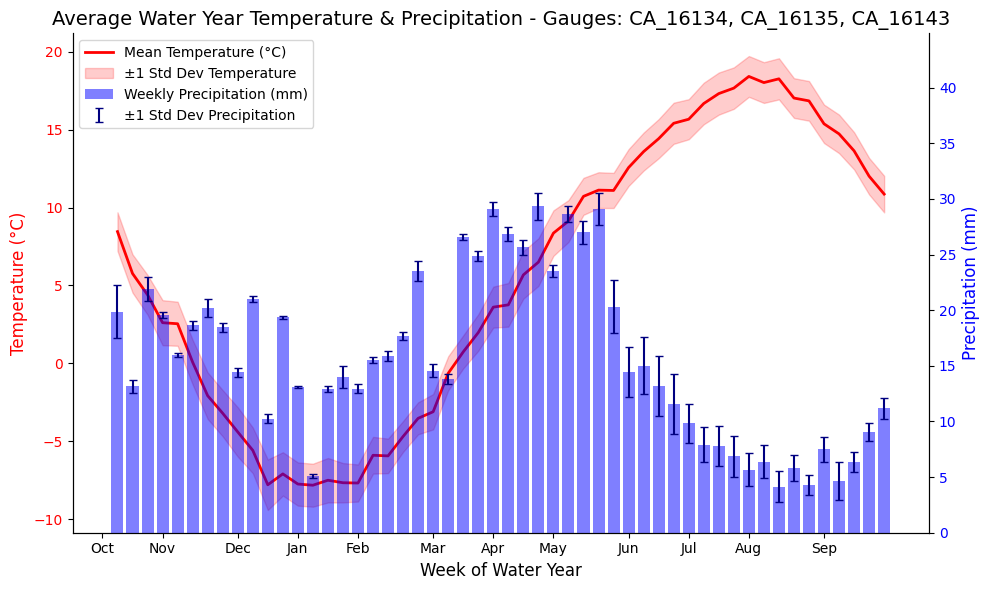

In [13]:
fig, _= plot_water_year_temperature_precipitation(group_data["ca_ts_data"], gauges_in_cluster)

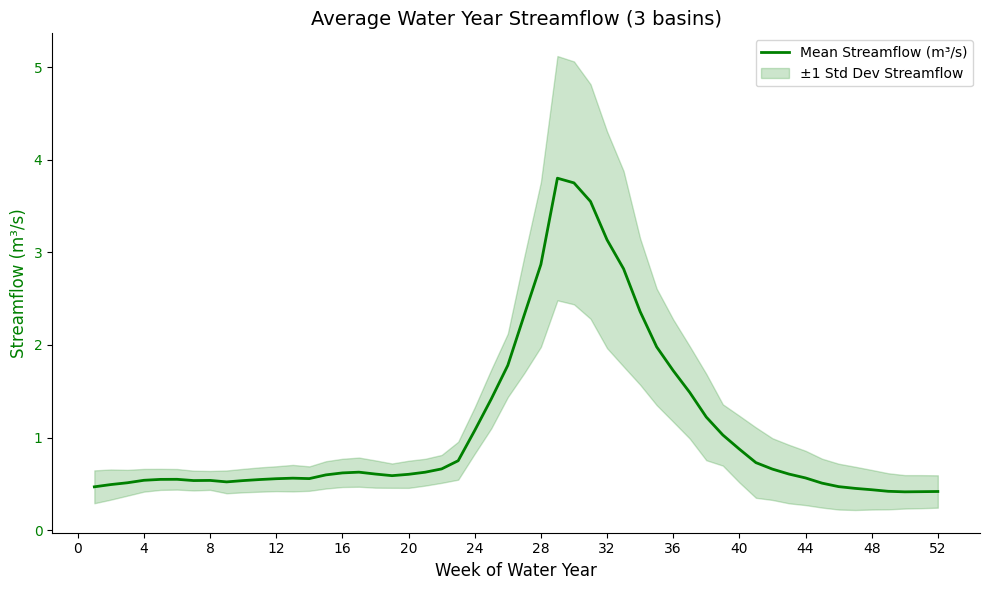

In [14]:
# Add streamflow to the plot
basin_id = gauges_in_cluster # Can be a single string or list of strings


# Function to compute aggregated statistics across multiple basins
def create_water_year_aggregates_streamflow(
    df: pd.DataFrame,
    basin_ids: Union[str, List[str]],
    basin_id_col: str,
    date_col: str,
    agg_dict: Dict[str, str] = None,
) -> pd.DataFrame:
    """
    Create weekly water year aggregates for streamflow. If multiple basins are provided,
    it computes the overall mean and standard deviation across basins; for a single basin,
    standard deviation is set to zero.

    Parameters:
        df: DataFrame with time series data.
        basin_ids: Single basin ID or list of basin IDs.
        basin_id_col: Column name for basin identifier.
        date_col: Column name for date.
        agg_dict: Dictionary of columns and aggregation functions. Defaults to {"streamflow": "mean"}.

    Returns:
        DataFrame with weekly aggregated mean and (if applicable) std deviation.
    """
    if agg_dict is None:
        agg_dict = {"streamflow": "mean"}

    # Ensure basin_ids is a list
    if isinstance(basin_ids, str):
        basin_ids = [basin_ids]

    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df[df[basin_id_col].isin(basin_ids)]

    if df.empty:
        print(f"No data found for {basin_id_col} values: {basin_ids}")
        return pd.DataFrame()

    # Compute water year (October start)
    df["water_year"] = df[date_col].apply(
        lambda x: x.year if x.month < 10 else x.year + 1
    )
    df = df.sort_values([basin_id_col, "water_year", date_col])

    # Compute start date for each basin & water year, then day and week of water year
    df["start_date"] = df.groupby([basin_id_col, "water_year"])[date_col].transform(
        "min"
    )
    df["day_of_water_year"] = (df[date_col] - df["start_date"]).dt.days
    df["week"] = (df["day_of_water_year"] // 7) + 1
    df["week"] = df["week"].clip(upper=52)

    if len(basin_ids) > 1:
        # First, calculate weekly aggregates for each basin and water year
        weekly_data = (
            df.groupby([basin_id_col, "water_year", "week"]).agg(agg_dict).reset_index()
        )
        # Then, average over water years for each basin
        basin_weekly_avg = (
            weekly_data.groupby([basin_id_col, "week"])
            .agg({col: "mean" for col in agg_dict.keys()})
            .reset_index()
        )
        # Finally, compute overall mean and std across basins for each week
        result = basin_weekly_avg.groupby("week").agg(
            {col: ["mean", "std"] for col in agg_dict.keys()}
        )
        result.columns = [f"{col[0]}_{col[1]}" for col in result.columns]
        result = result.reset_index()
    else:
        # Single basin: aggregate over water years and compute weekly average.
        weekly_data = df.groupby(["water_year", "week"]).agg(agg_dict).reset_index()
        result = weekly_data.groupby("week").agg(
            {col: "mean" for col in agg_dict.keys()}
        )
        # For a single basin, set the std column to zero.
        for col in agg_dict.keys():
            result[f"{col}_std"] = 0
        result = result.reset_index()

    return result


# Use the revised function for streamflow
agg_dict = {"streamflow": "mean"}
avg_weekly = create_water_year_aggregates_streamflow(
    group_data["ca_ts_data"], basin_id, "gauge_id", "date", agg_dict
)

fig, ax1 = plt.subplots(figsize=(10, 6))
weeks = avg_weekly["week"]

# Use different column names depending on whether multiple basins are provided.
if isinstance(basin_id, list) and len(basin_id) > 1:
    streamflow_mean = avg_weekly["streamflow_mean"]
    streamflow_std = avg_weekly["streamflow_std"].fillna(0)
else:
    streamflow_mean = avg_weekly["streamflow"]
    streamflow_std = avg_weekly["streamflow_std"]

ax1.plot(
    weeks,
    streamflow_mean,
    color="green",
    label="Mean Streamflow (m³/s)",
    linewidth=2,
)

# Only add std band if multiple basins (std > 0)
if isinstance(basin_id, list) and len(basin_id) > 1:
    ax1.fill_between(
        weeks,
        streamflow_mean - streamflow_std,
        streamflow_mean + streamflow_std,
        color="green",
        alpha=0.2,
        label="±1 Std Dev Streamflow",
    )

ax1.set_xlabel("Week of Water Year", fontsize=12)
ax1.set_ylabel("Streamflow (m³/s)", color="green", fontsize=12)
ax1.tick_params(axis="y", labelcolor="green")
ax1.set_xticks(np.arange(0, 53, step=4))

basin_info = (
    f"({len(basin_id)} basins)" if isinstance(basin_id, list) else f"(Basin {basin_id})"
)
ax1.set_title(f"Average Water Year Streamflow {basin_info}", fontsize=14)
ax1.legend()
sns.despine()

plt.tight_layout()
plt.show()


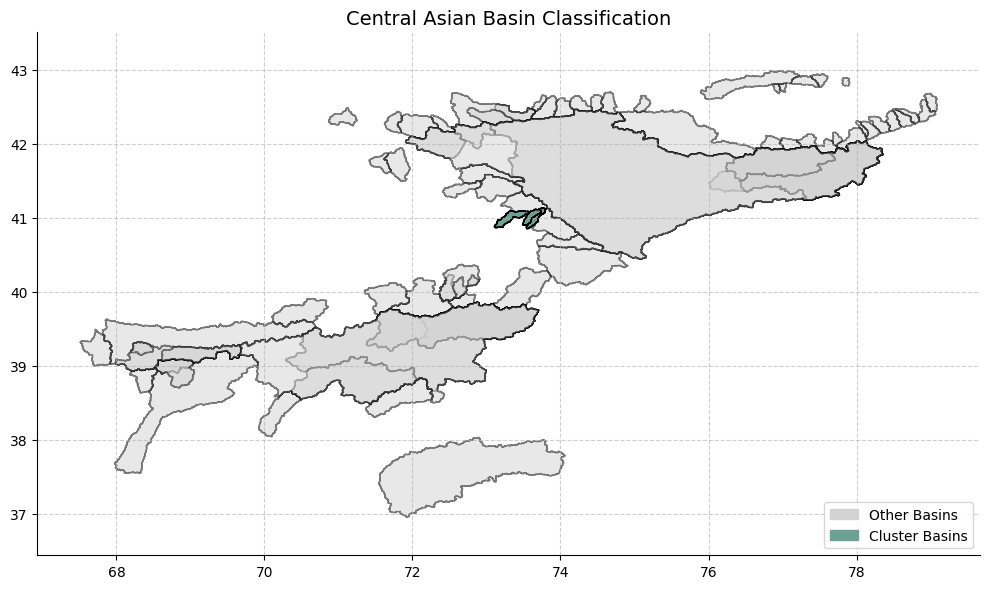

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Load and process the data
path_to_kgz_basins = "/Users/cooper/Desktop/CAMELS-CH/data/CA_raw/basin_outline/kyrgyzstan/HRU_KRG_ML_MODEL_BASINS_1d.shp"
path_to_tjik_basins = "/Users/cooper/Desktop/CAMELS-CH/data/CA_raw/basin_outline/tajikistan/HRU_TAJIK_ML_MODEL_BASINS_1d.shp"

# Load basin geometries and ensure consistent projection
kgz_basins = gpd.read_file(path_to_kgz_basins).to_crs(epsg=4326)
tjik_basins = gpd.read_file(path_to_tjik_basins).to_crs(epsg=4326)

# Create masks for different basin categories
# Make sure the column names match your shapefile attributes
kgz_mask = (
    kgz_basins["CODE"].astype(str).apply(lambda x: f"CA_{x}" in gauges_in_cluster)
)
tjik_mask = (
    tjik_basins["CODE"].astype(str).apply(lambda x: f"CA_{x}" in gauges_in_cluster)
)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot regular basins
kgz_basins[~kgz_mask].plot(ax=ax, color="lightgrey", edgecolor="black", alpha=0.5)
tjik_basins[~tjik_mask].plot(ax=ax, color="lightgrey", edgecolor="black", alpha=0.5)

# Plot improved basins - check if there are any matches before plotting
if kgz_mask.any():
    kgz_basins[kgz_mask].plot(ax=ax, color="#6BA292", edgecolor="black")

if tjik_mask.any():
    tjik_basins[tjik_mask].plot(ax=ax, color="#6BA292", edgecolor="black")

# Manually add legend
legend_patches = [
    mpatches.Patch(color="lightgrey", label="Other Basins"),
    mpatches.Patch(color="#6BA292", label="Cluster Basins"),
]

ax.legend(handles=legend_patches, loc="lower right")

# Customize the plot
plt.axis("equal")
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Central Asian Basin Classification", fontsize=14)

# Add contextual information if needed
if not (kgz_mask.any() or tjik_mask.any()):
    plt.figtext(
        0.5,
        0.01,
        "Note: No basins matched the cluster criteria",
        ha="center",
        fontsize=10,
        style="italic",
    )

# Adjust layout to prevent legend cutoff
plt.tight_layout()
sns.despine()

plt.show()

In [10]:
gauges_in_cluster

['CA_15013',
 'CA_15016',
 'CA_15020',
 'CA_15022',
 'CA_15025',
 'CA_15030',
 'CA_15034',
 'CA_15039',
 'CA_15040',
 'CA_15044',
 'CA_15045',
 'CA_15049',
 'CA_15051',
 'CA_15054',
 'CA_15069',
 'CA_15070',
 'CA_15081',
 'CA_15083',
 'CA_15090',
 'CA_15102',
 'CA_15149',
 'CA_15171',
 'CA_15189',
 'CA_15194',
 'CA_15212',
 'CA_15214',
 'CA_15215',
 'CA_15216',
 'CA_15256',
 'CA_15259',
 'CA_15278',
 'CA_15283',
 'CA_15285',
 'CA_15287',
 'CA_15312',
 'CA_16055',
 'CA_16059',
 'CA_16068',
 'CA_16070',
 'CA_16096',
 'CA_16100',
 'CA_16101',
 'CA_16105',
 'CA_16121',
 'CA_16127',
 'CA_16136',
 'CA_16139',
 'CA_16146',
 'CA_16151',
 'CA_16153',
 'CA_16158',
 'CA_16159',
 'CA_16160',
 'CA_16161',
 'CA_16169',
 'CA_16176',
 'CA_16205',
 'CA_16487',
 'CA_16510',
 'CA_17050',
 'CA_17077',
 'CA_17082',
 'CA_17100',
 'CA_17110',
 'CA_17137',
 'CA_17147',
 'CA_17150',
 'CA_17202',
 'CA_17288',
 'CA_17325',
 'CA_17329',
 'CA_17338',
 'CA_17344',
 'CA_17453',
 'CA_17462']